# Offline Deep Reinforcement Learning for Sepsis Treatment Recommendation
## Baseline Models

This notebook trains three families of behaviour-cloning baselines:
1. **Tabular** – Logistic Regression, Random Forest, MLP
2. **Imaging** – ResNet-18 with a frozen backbone
3. **Behaviour Cloning (MDP format)** – MLP on preprocessed MDP transitions


---
## 0. Imports & Output Directories

In [4]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# ── Project root (parent of notebooks/) ──────────────────────────────────────
PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
# Using the same pattern as W2_data_exploration: src/ is added directly,
# so imports are 'from tabular_baselines import ...' (not 'from src.xxx')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix

# ── src/ modules ──────────────────────────────────────────────────────────────
from tabular_baselines import run_tabular_baselines
from imaging_baseline import (
    prepare_imaging_splits,
    build_data_loaders,
    build_resnet18,
    train_resnet18,
    evaluate_resnet18,
)
from behaviour_cloning import (
    load_mdp_transitions,
    split_and_scale_mdp,
    train_and_evaluate_bc,
)
from results_utils import build_results_table, print_results_table, save_results_csv
# Also import STATE_COLS and column name constants from data_preprocessing
# so this notebook stays in sync with the preprocessing pipeline
from data_preprocessing import (
    STATE_COLS, ID_COL, TIME_COL, FLUID_COL, VASO_COL, SURVIVAL_COL,
)

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures', 'baselines')
DATA_DIR    = os.path.join(PROJECT_ROOT, 'data', 'results')

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

def fig_path(fname):  return os.path.join(FIGURES_DIR, fname)
def data_path(fname): return os.path.join(DATA_DIR,    fname)

# ── Reproducibility & style ───────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = {
    'blue'  : '#2C7BB6', 'red'    : '#D7191C',
    'green' : '#1A9641', 'purple' : '#7B2D8B',
    'orange': '#FF7F00', 'gold'   : '#D4A017',
}
C1, C2, C3 = PALETTE['blue'], PALETTE['red'], PALETTE['green']

plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.figsize'   : (12, 5),
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})
sns.set_theme(style='whitegrid')

print(f'Figures  → {FIGURES_DIR}')
print(f'CSV data → {DATA_DIR}')
print('All imports successful.')

Figures  → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines
CSV data → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results
All imports successful.


---
## 1. Data Loading

We load the **fully preprocessed** dataframe produced by `W2_data_exploration.ipynb`
(Section 12 — saved to `../data/sepsis_preprocessed.csv`).  
This file already contains cleaned state columns, the SOFA/SIRS engineered features,
and the discretised `action_combined` column (0–24, 5×5 grid).

In [5]:
# Load the artifact saved by W2_data_exploration.ipynb  (Section 12)
CSV_PATH = os.path.join(PROJECT_ROOT, 'data', 'sepsis_preprocessed.csv')
df_clean = pd.read_csv(CSV_PATH)

print(f'Shape           : {df_clean.shape}')
print(f'Unique patients : {df_clean[ID_COL].nunique():,}')
print(f'Columns present : {list(df_clean.columns[:8])} ...')

# Verify the action column exists (created by discretize_actions in feature_engineering.py)
assert 'action_combined' in df_clean.columns, (
    "'action_combined' column not found.  "
    "Make sure W2_data_exploration.ipynb has been run and saved sepsis_preprocessed.csv."
)

# STATE_COLS is imported from data_preprocessing — use extended columns if present
# (build_extended_state adds SOFA_score, SIRS_score, SOFA_delta, severity flags)
EXTENDED_COLS = [c for c in df_clean.columns
                 if c not in [ID_COL, TIME_COL, FLUID_COL, VASO_COL,
                               SURVIVAL_COL, 'action_combined', 'cluster',
                               'Mech', 'OutputTotal', 'Output4H',
                               'Hyperlactatemia', 'SepticShock_proxy',
                               'MetabolicAcidosis', 'SIRS_positive']]

X = df_clean[EXTENDED_COLS].values          # (n_samples, n_features)
y = df_clean['action_combined'].values      # (n_samples,), integers 0..24

print(f'\nFeatures used   : {len(EXTENDED_COLS)}')
print(f'Total samples   : {len(X):,}')
print(f'Unique actions  : {np.unique(y).size} / 25')

Shape           : (43280, 75)
Unique patients : 2,164
Columns present : ['Age', 'HR', 'SysBP', 'MeanBP', 'DiaBP', 'RR', 'K', 'Na'] ...

Features used   : 61
Total samples   : 43,280
Unique actions  : 25 / 25


### 1.1 Action Distribution

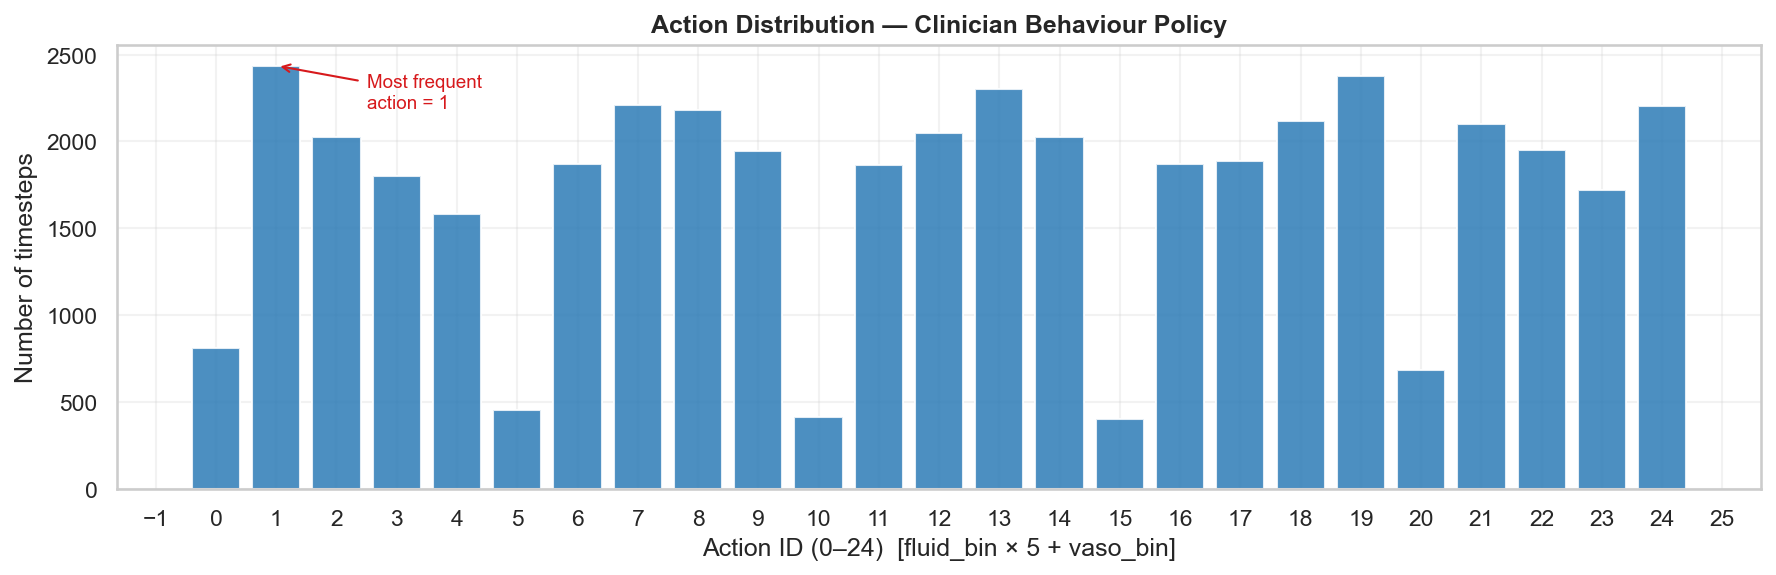

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\action_distribution.png


In [6]:
action_counts = pd.Series(y).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(action_counts.index, action_counts.values, color=C1, edgecolor='white', alpha=0.85)
ax.set_xlabel('Action ID (0–24)  [fluid_bin × 5 + vaso_bin]')
ax.set_ylabel('Number of timesteps')
ax.set_title('Action Distribution — Clinician Behaviour Policy', fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# Annotate the most frequent action
top_action = action_counts.idxmax()
ax.annotate(
    f'Most frequent\naction = {top_action}',
    xy=(top_action, action_counts[top_action]),
    xytext=(top_action + 1.5, action_counts[top_action] * 0.9),
    arrowprops=dict(arrowstyle='->', color=C2),
    color=C2, fontsize=9,
)
plt.tight_layout()
plt.savefig(fig_path('action_distribution.png'), bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path('action_distribution.png')}")

---
## 2. Train / Validation / Test Split (Stratified by Action)

Split: **64 % train — 16 % validation — 20 % test**.  
MinMax scaling is fitted **only on the training fold** to prevent data leakage.

In [7]:
# Step 1: separate test (20 %) from train+val (80 %)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
# Step 2: separate val (16/80 = 20 %) from train (64/80 = 80 %)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=RANDOM_STATE, stratify=y_tv
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}   ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}   ({len(X_test)/len(X)*100:.0f}%)')

# Fit scaler on the training set only
scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Train : (27699, 61)  (64%)
Val   : (6925, 61)   (16%)
Test  : (8656, 61)   (20%)


---
## 3. Tabular Baselines

Trains and evaluates Logistic Regression, Random Forest, and MLP
via `tabular_baselines.run_tabular_baselines`.

In [8]:
tabular_results = run_tabular_baselines(
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    random_state=RANDOM_STATE,
)

lr_result, rf_result, mlp_result = tabular_results

Logistic Regression            | Accuracy: 0.9968 | Macro F1: 0.9878
Random Forest                  | Accuracy: 0.9953 | Macro F1: 0.9948
MLP (tabular)                  | Accuracy: 1.0000 | Macro F1: 1.0000


### 3.1 Confusion Matrices — Tabular Models

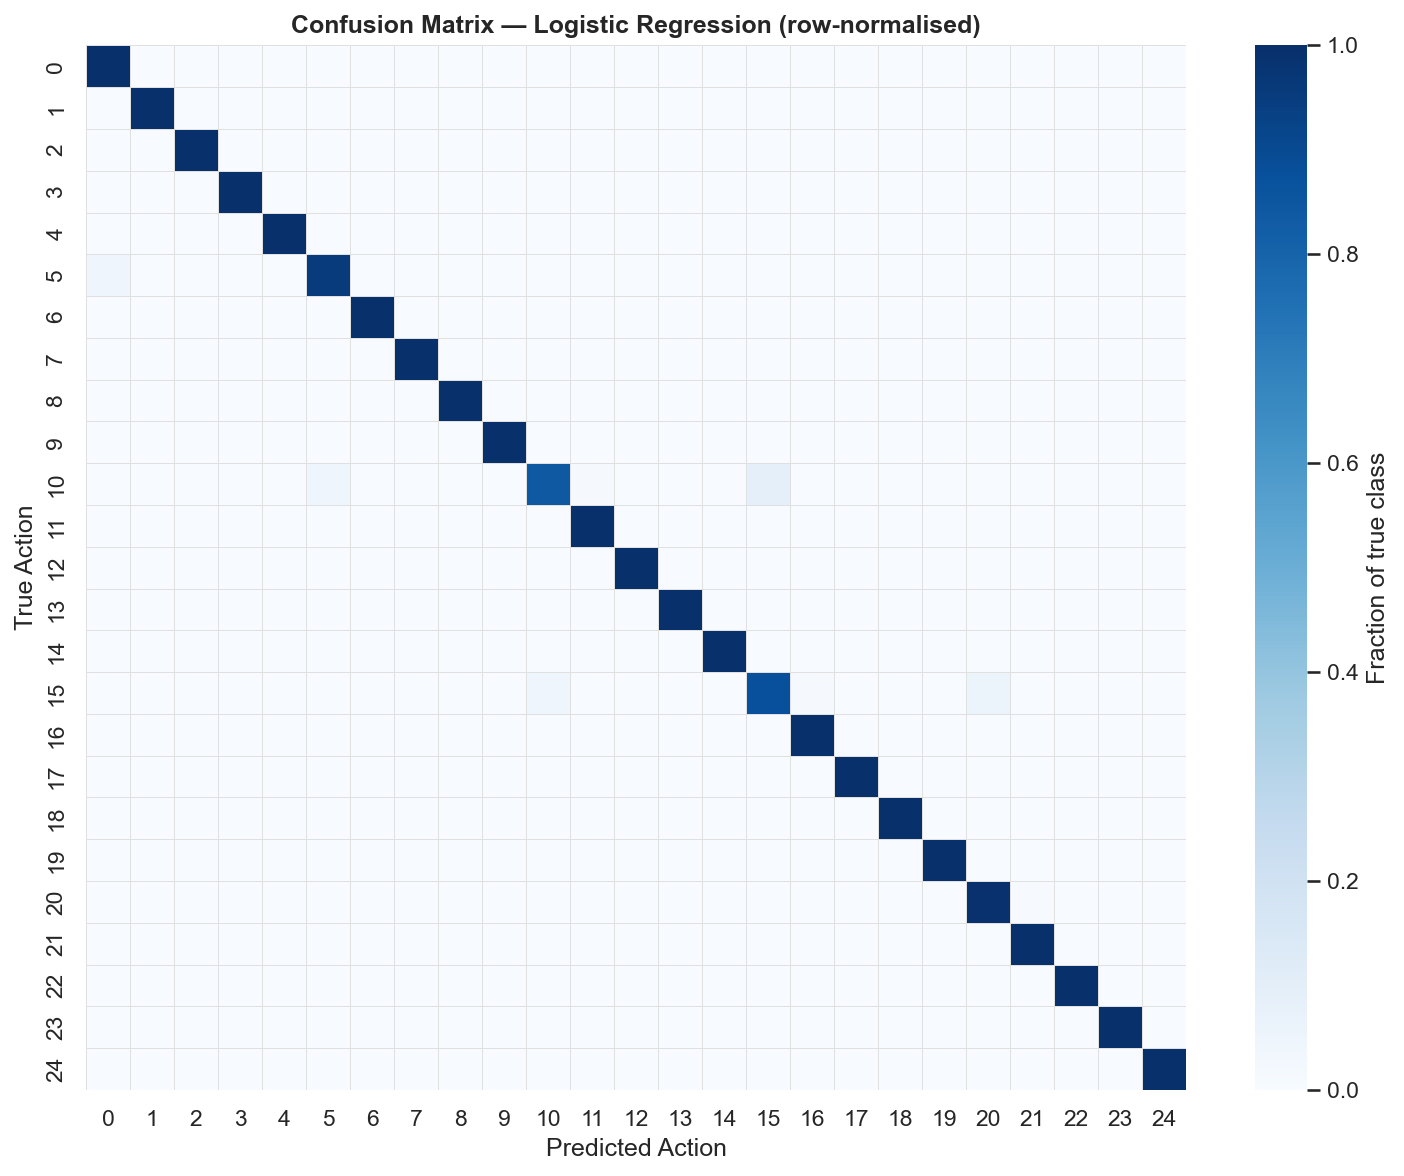

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_lr.png


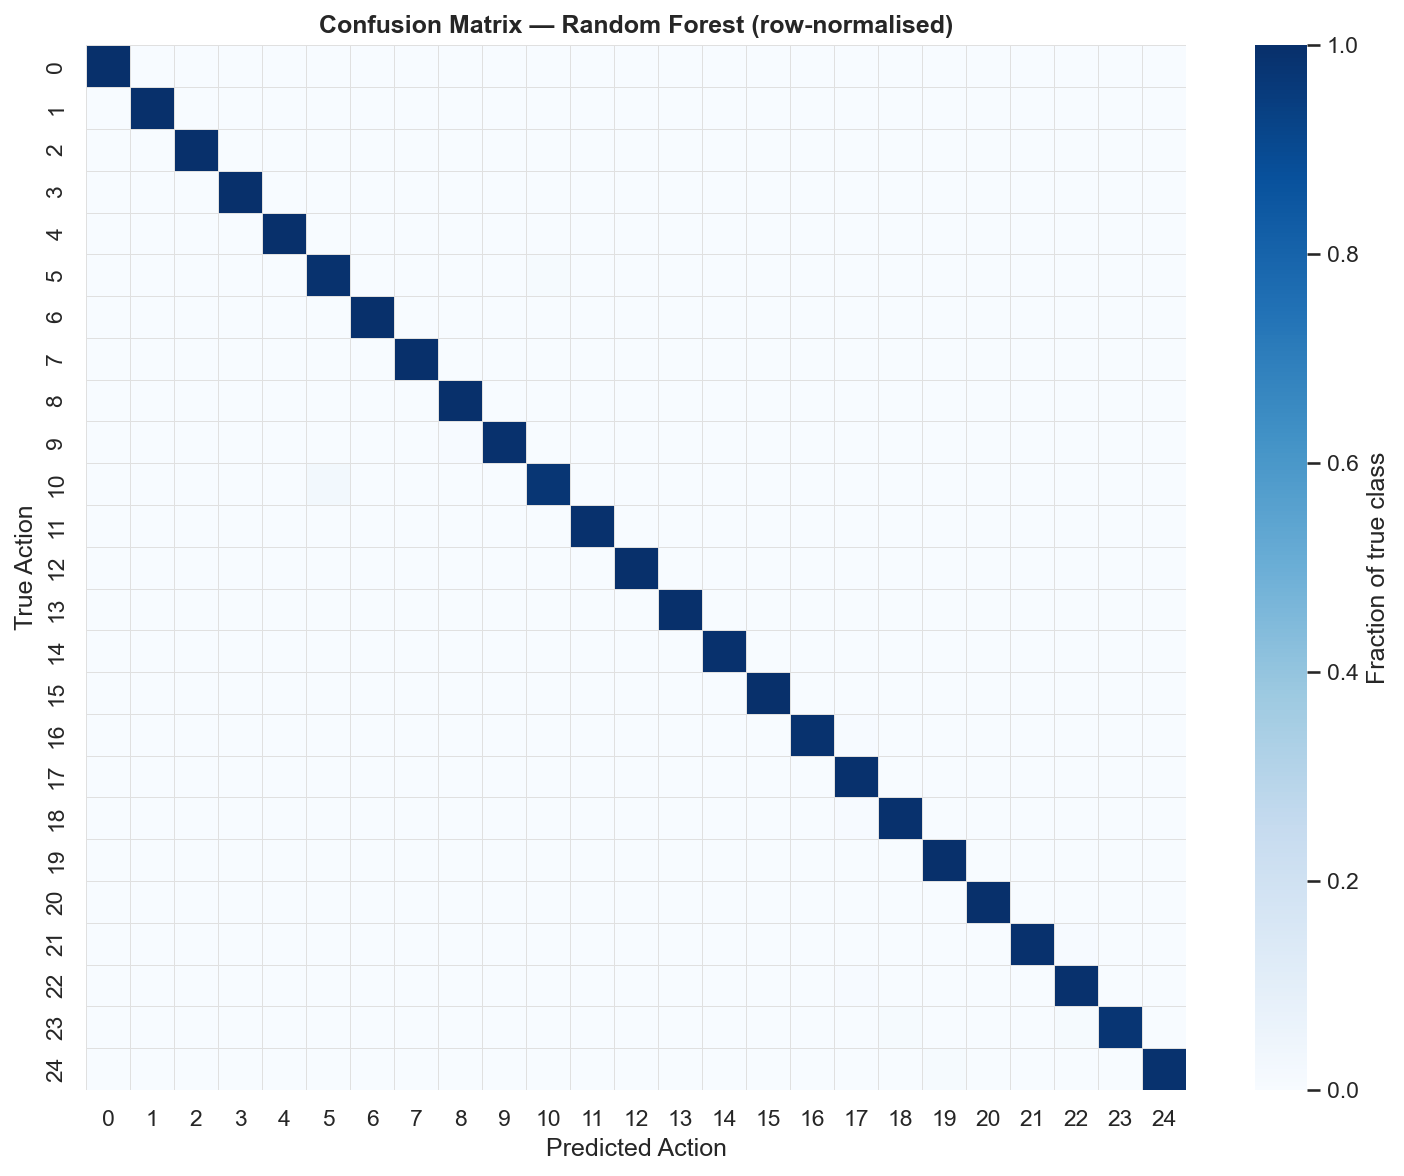

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_rf.png


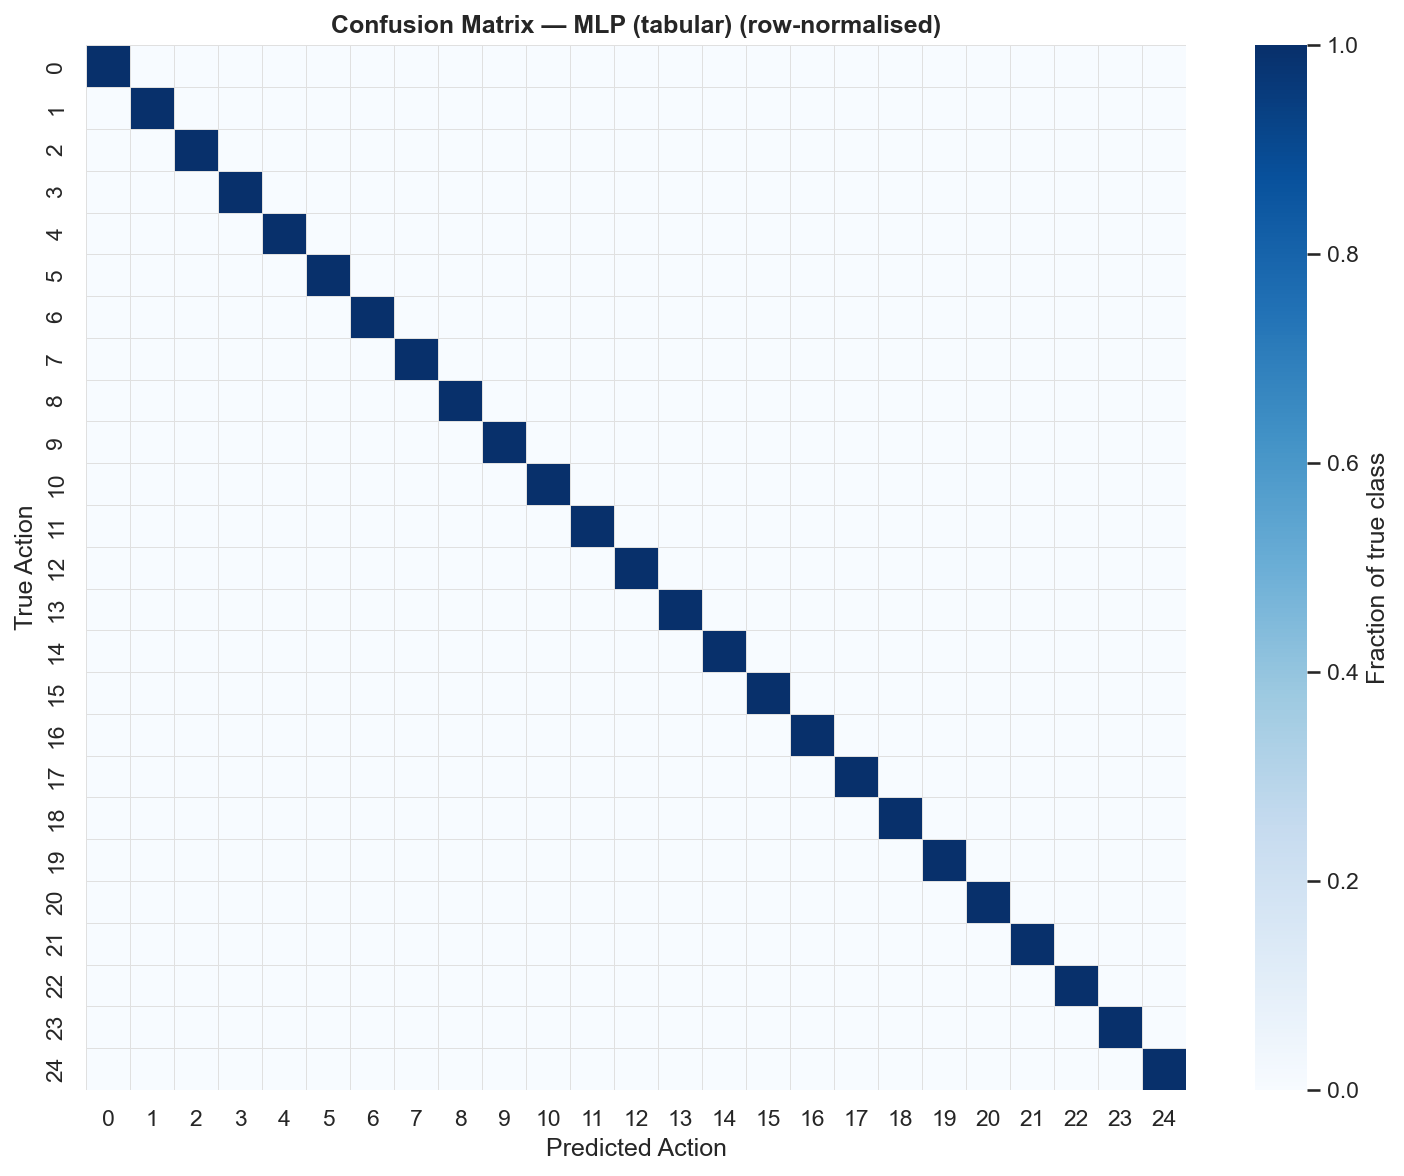

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_mlp.png


In [9]:
def plot_confusion_matrix(y_true, y_pred, title: str, save_name: str):
    """Plot and save a row-normalised confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(25), normalize='true')
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, ax=ax, cmap='Blues', vmin=0, vmax=1,
        xticklabels=np.arange(25), yticklabels=np.arange(25),
        linewidths=0.3, linecolor='#e0e0e0',
        cbar_kws={'label': 'Fraction of true class'},
    )
    ax.set_xlabel('Predicted Action')
    ax.set_ylabel('True Action')
    ax.set_title(f'Confusion Matrix — {title} (row-normalised)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_path(save_name), bbox_inches='tight')
    plt.show()
    print(f'Saved → {fig_path(save_name)}')

plot_confusion_matrix(
    y_test, lr_result['model'].predict(X_test_scaled),
    'Logistic Regression', 'confusion_matrix_lr.png'
)
plot_confusion_matrix(
    y_test, rf_result['model'].predict(X_test_scaled),
    'Random Forest', 'confusion_matrix_rf.png'
)
plot_confusion_matrix(
    y_test, mlp_result['model'].predict(X_test_scaled),
    'MLP (tabular)', 'confusion_matrix_mlp.png'
)

### 3.2 Save Tabular Predictions

In [10]:
df_tab_preds = pd.DataFrame({
    'y_true'    : y_test,
    'y_pred_lr' : lr_result['model'].predict(X_test_scaled),
    'y_pred_rf' : rf_result['model'].predict(X_test_scaled),
    'y_pred_mlp': mlp_result['model'].predict(X_test_scaled),
})
df_tab_preds.to_csv(data_path('tabular_predictions.csv'), index=False)
print(f"Saved → {data_path('tabular_predictions.csv')}")
df_tab_preds.head()

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results\tabular_predictions.csv


,y_true,y_pred_lr,y_pred_rf,y_pred_mlp
0,5,5,5,5
1,19,19,19,19
2,9,9,9,9
3,19,19,19,19
4,11,11,11,11


---
## 4. Imaging Baseline — ResNet-18 (Frozen Backbone)

Each patient episode is converted on-the-fly into a `T_max × 35` heatmap,
resized to 224 × 224, and replicated to 3 channels.  
Only the classification head is fine-tuned; the ResNet-18 backbone stays frozen.

> **Note:** The imaging baseline operates at **patient level** (one label per patient
> = most-frequent action), while tabular and BC baselines operate at **timestep level**.
> This is why the split and sample counts differ.

In [11]:
import torch
import torch.nn as nn
import gc

# ── Data preparation (patient-level) ─────────────────────────────────────────
# prepare_imaging_splits expects the raw (unscaled) dataframe with PatientID,
# Timepoints, state columns, and action_combined.  It normalises internally.
df_img, train_split, val_split, test_split = prepare_imaging_splits(
    df_clean,
    state_cols=STATE_COLS,   # base 35 physiological features for the heatmap
    random_state=RANDOM_STATE,
)

train_loader, val_loader, test_loader = build_data_loaders(
    df_img, train_split, val_split, test_split,
    batch_size=32, state_cols=STATE_COLS,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device}')
print(f'Train patients  : {len(train_split[0])}')
print(f'Val patients    : {len(val_split[0])}')
print(f'Test patients   : {len(test_split[0])}')

Imaging split — Train: 1384 patients, Val: 347, Test: 433
Device          : cpu
Train patients  : 1384
Val patients    : 347
Test patients   : 433


In [12]:
# ── Model ─────────────────────────────────────────────────────────────────────
resnet = build_resnet18(n_actions=25, dropout=0.5)

# ── Training via src/imaging_baseline.py ─────────────────────────────────────
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, 'data', 'best_resnet18_sepsis.pth')

resnet, epoch_logs = train_resnet18(
    resnet, train_loader, val_loader,
    n_epochs=20, lr=1e-3,
    save_path=CHECKPOINT_PATH,
    device=device,
    return_logs=True,   # returns (model, logs) — see note below
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pc/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:17<00:00, 2.75MB/s]


Epoch  1/20 | Loss: 3.1284 | Val Acc: 0.1009
Epoch  2/20 | Loss: 3.0201 | Val Acc: 0.0980
Epoch  3/20 | Loss: 2.9434 | Val Acc: 0.1412
Epoch  4/20 | Loss: 2.8528 | Val Acc: 0.1354
Epoch  5/20 | Loss: 2.8301 | Val Acc: 0.1758
Epoch  6/20 | Loss: 2.7480 | Val Acc: 0.1816
Epoch  7/20 | Loss: 2.6938 | Val Acc: 0.1758
Epoch  8/20 | Loss: 2.6624 | Val Acc: 0.1614
Epoch  9/20 | Loss: 2.6152 | Val Acc: 0.1729
Epoch 10/20 | Loss: 2.5823 | Val Acc: 0.1729
Epoch 11/20 | Loss: 2.5662 | Val Acc: 0.1671
Epoch 12/20 | Loss: 2.5593 | Val Acc: 0.1902
Epoch 13/20 | Loss: 2.5017 | Val Acc: 0.2536
Epoch 14/20 | Loss: 2.4675 | Val Acc: 0.2133
Epoch 15/20 | Loss: 2.4678 | Val Acc: 0.1960
Epoch 16/20 | Loss: 2.4831 | Val Acc: 0.2248
Epoch 17/20 | Loss: 2.4813 | Val Acc: 0.2363
Epoch 18/20 | Loss: 2.3863 | Val Acc: 0.2305
Epoch 19/20 | Loss: 2.4212 | Val Acc: 0.2104
Epoch 20/20 | Loss: 2.4411 | Val Acc: 0.2392

Best val accuracy: 0.2536 — checkpoint: c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendatio

### 4.1 Training Curve

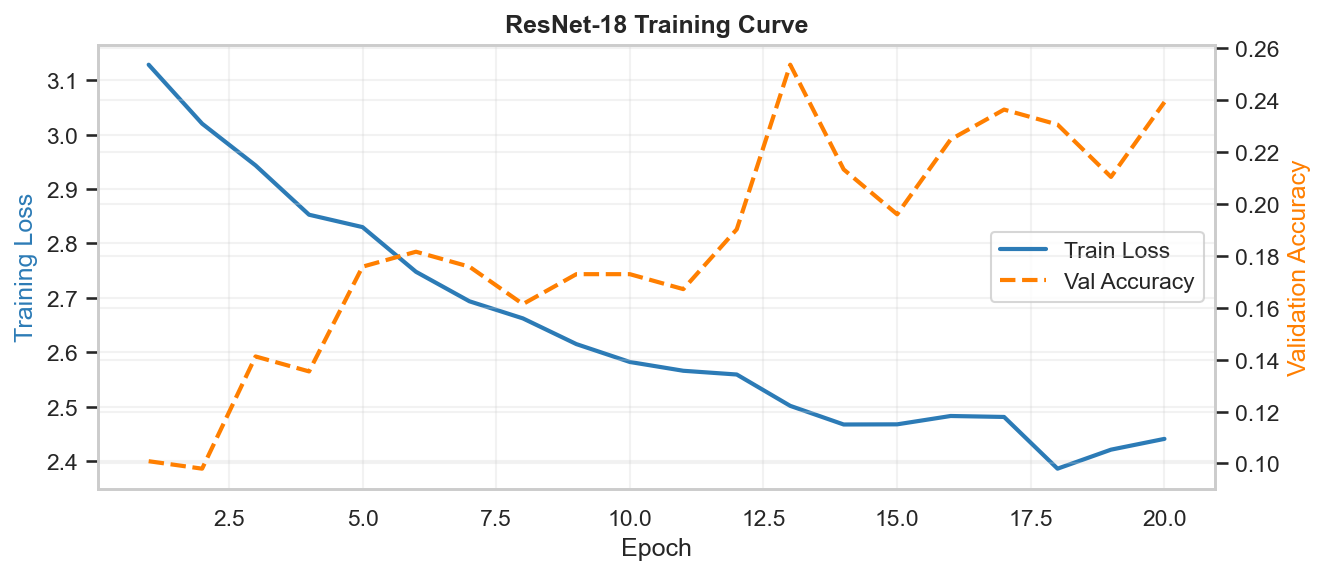

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\resnet18_training_curve.png


In [13]:
df_logs = pd.DataFrame(epoch_logs)   # columns: epoch, loss, val_acc

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(df_logs['epoch'], df_logs['loss'],    color=C1,              lw=2, label='Train Loss')
ax2.plot(df_logs['epoch'], df_logs['val_acc'], color=PALETTE['orange'], lw=2, ls='--', label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss',      color=C1)
ax2.set_ylabel('Validation Accuracy', color=PALETTE['orange'])
ax1.set_title('ResNet-18 Training Curve', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.savefig(fig_path('resnet18_training_curve.png'), bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path('resnet18_training_curve.png')}")

### 4.2 Test Evaluation & Confusion Matrix

ResNet-18 (frozen)             | Accuracy: 0.2379 | Macro F1: 0.1270


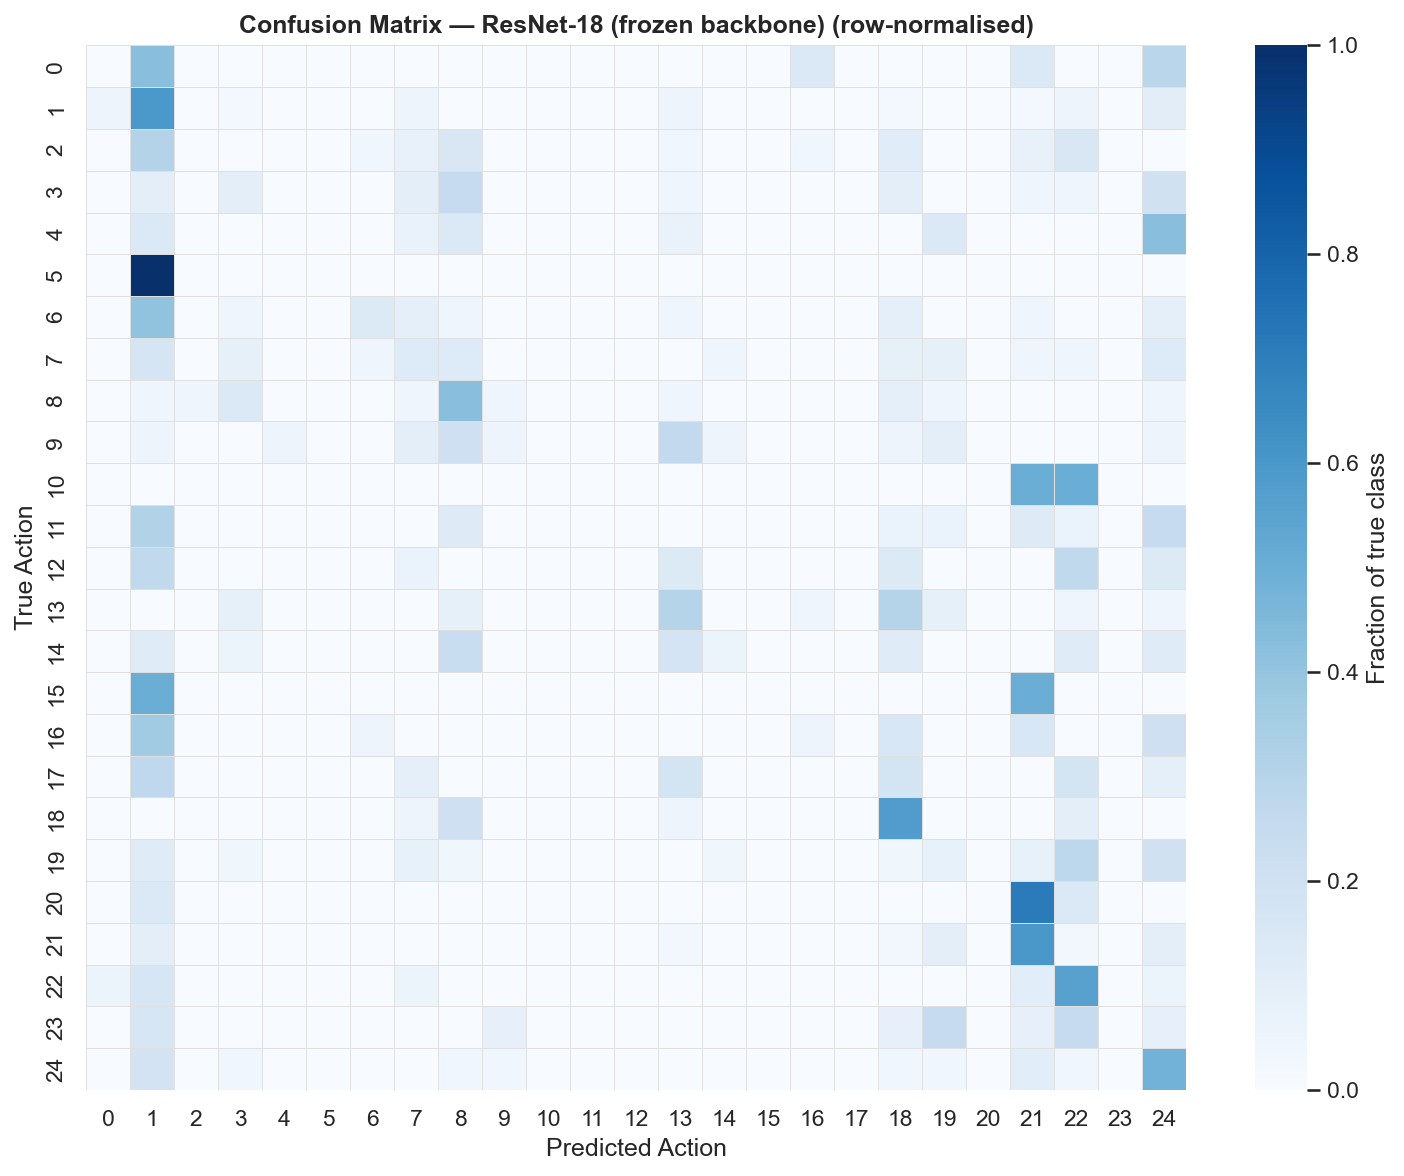

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_resnet18.png


In [14]:
resnet_result = evaluate_resnet18(resnet, test_loader, device=device)

# Collect predictions for the confusion matrix
resnet.eval()
resnet_preds, resnet_true = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, pred = torch.max(resnet(images), 1)
        resnet_preds.extend(pred.cpu().numpy())
        resnet_true.extend(labels.numpy())

plot_confusion_matrix(
    resnet_true, resnet_preds,
    'ResNet-18 (frozen backbone)', 'confusion_matrix_resnet18.png'
)

---
## 5. Behaviour Cloning — MDP Format

Uses the same MLP architecture as the tabular baseline, but the input comes
from the MDP transitions stored in `../data/preprocessed/sepsis_preprocessed.npz`
(produced by Section 12 of `W2_data_exploration.ipynb`).

In [16]:
NPZ_PATH = os.path.join(PROJECT_ROOT, 'data', 'preprocessed', 'sepsis_mdp_dataset.npz')

states, actions_mdp = load_mdp_transitions(NPZ_PATH)

(
    X_mdp_train, X_mdp_val, X_mdp_test,
    y_mdp_train, y_mdp_val, y_mdp_test,
    scaler_mdp,
) = split_and_scale_mdp(states, actions_mdp, random_state=RANDOM_STATE)

bc_result = train_and_evaluate_bc(
    X_mdp_train, y_mdp_train,
    X_mdp_test,  y_mdp_test,
    random_state=RANDOM_STATE,
)

Loaded MDP transitions: states=(43279, 56), actions=(43279,)
MDP split — Train: (30295, 56), Val: (4328, 56), Test: (8656, 56)
Behaviour Cloning (MDP)        | Accuracy: 0.4778 | Macro F1: 0.4922


### 5.1 Confusion Matrix & Predictions — BC MDP

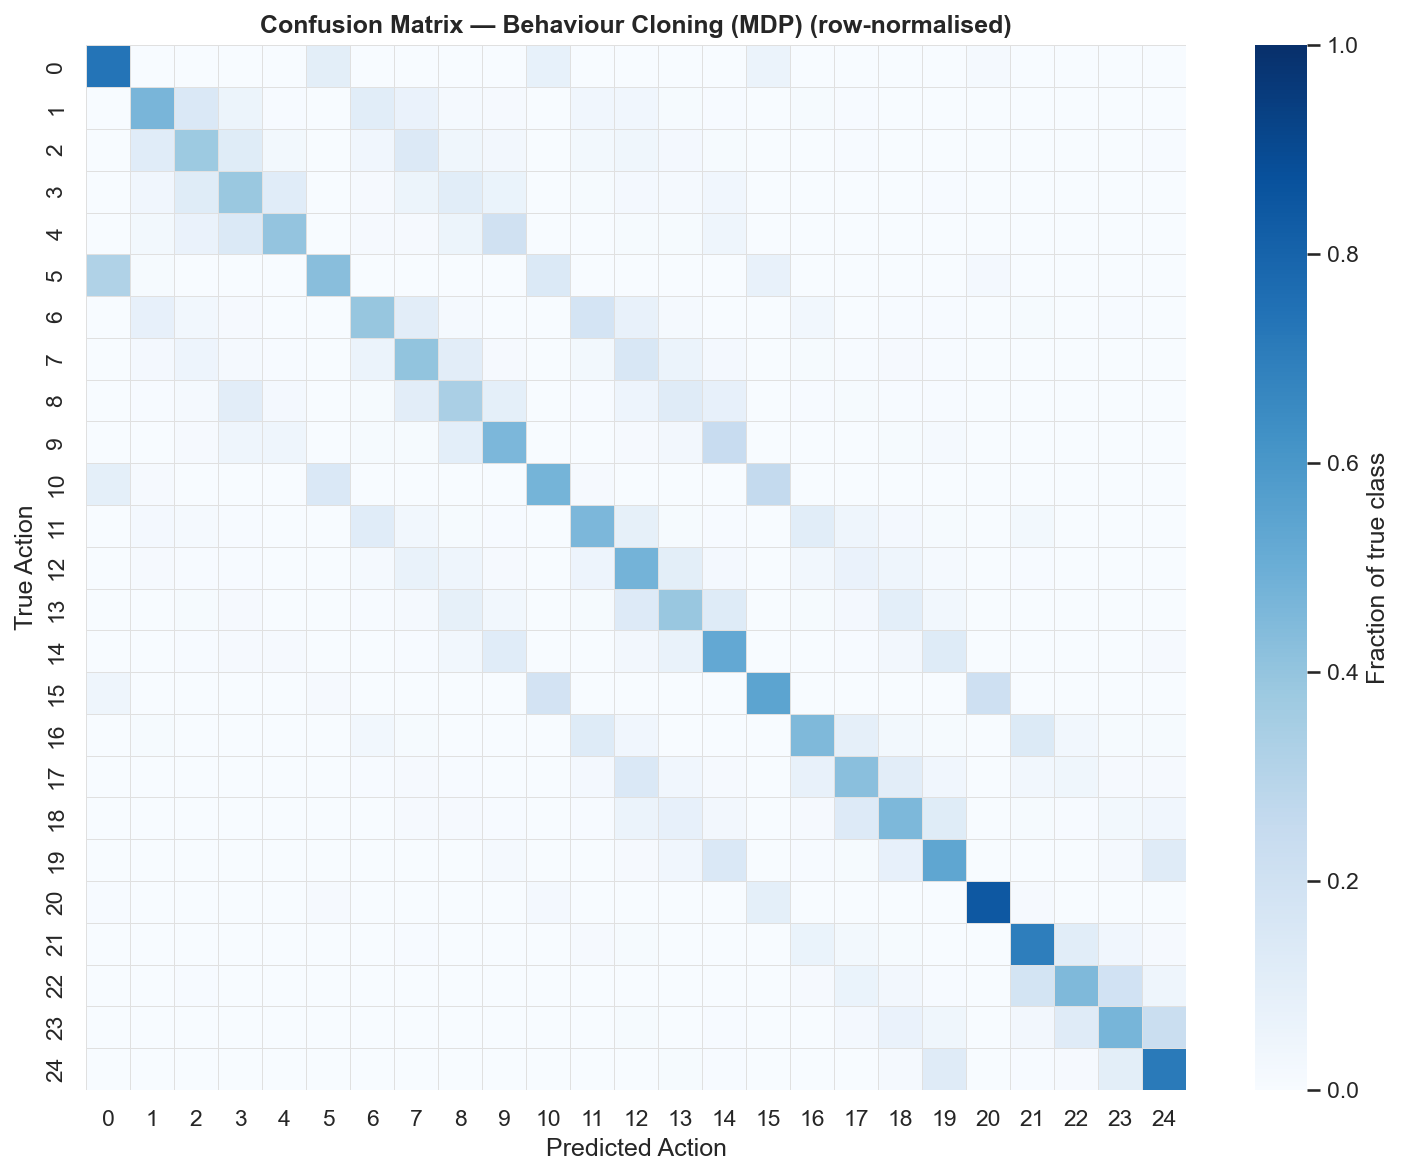

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\confusion_matrix_bc_mdp.png
Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results\bc_mdp_predictions.csv


In [17]:
bc_preds = bc_result['model'].predict(X_mdp_test)

plot_confusion_matrix(
    y_mdp_test, bc_preds,
    'Behaviour Cloning (MDP)', 'confusion_matrix_bc_mdp.png'
)

df_bc_preds = pd.DataFrame({'y_true': y_mdp_test, 'y_pred_bc': bc_preds})
df_bc_preds.to_csv(data_path('bc_mdp_predictions.csv'), index=False)
print(f"Saved → {data_path('bc_mdp_predictions.csv')}")

---
## 6. Results Summary

In [18]:
all_results = [lr_result, rf_result, mlp_result, resnet_result, bc_result]

df_results = build_results_table(all_results)
print_results_table(df_results)

save_results_csv(df_results, data_path('baseline_results.csv'))
df_results


Baseline Results Summary
                  Model  Accuracy  Macro F1
    Logistic Regression    0.9968    0.9878
          Random Forest    0.9953    0.9948
          MLP (tabular)    1.0000    1.0000
     ResNet-18 (frozen)    0.2379    0.1270
Behaviour Cloning (MDP)    0.4778    0.4922

Results saved to c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\data\results\baseline_results.csv


,Model,Accuracy,Macro F1
0,Logistic Regression,0.9968,0.9878
1,Random Forest,0.9953,0.9948
2,MLP (tabular),1.0000,1.0000
3,ResNet-18 (frozen),0.2379,0.1270
4,Behaviour Cloning (MDP),0.4778,0.4922


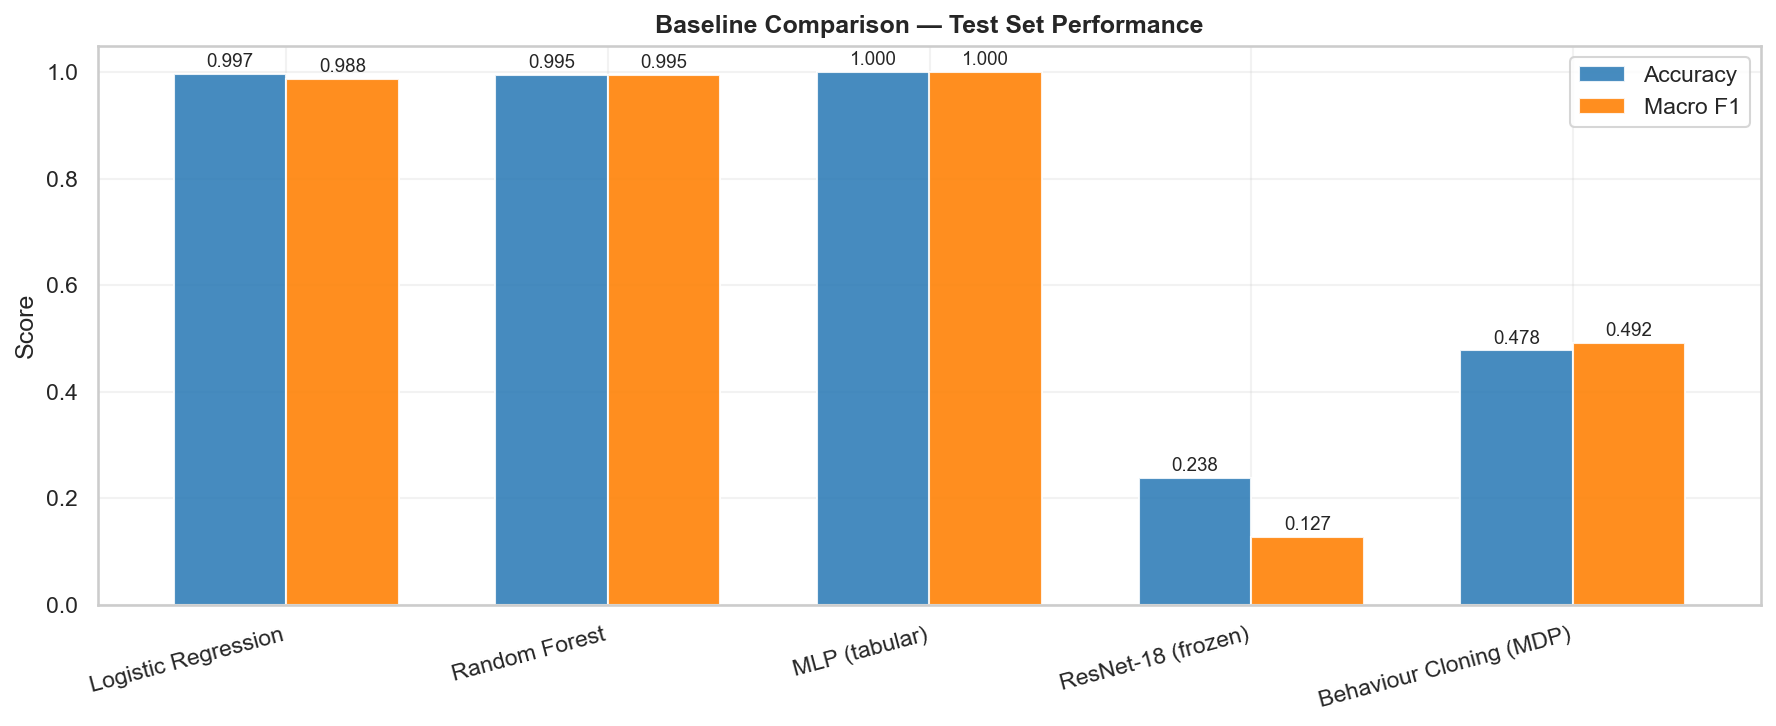

Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\baselines\baseline_comparison.png


In [19]:
x      = np.arange(len(df_results))
width  = 0.35
labels = df_results['Model'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width / 2, df_results['Accuracy'], width,
               label='Accuracy', color=C1, edgecolor='white', alpha=0.88)
bars2 = ax.bar(x + width / 2, df_results['Macro F1'], width,
               label='Macro F1', color=PALETTE['orange'], edgecolor='white', alpha=0.88)

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline Comparison — Test Set Performance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(fig_path('baseline_comparison.png'), bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path('baseline_comparison.png')}")